In [1]:
import pandas as pd
import numpy as np
import os

data_path = '/Users/luozifei/Desktop/Study/Tableau/Job Posting'

Files in directory:
  .DS_Store
  companies.csv
  industries.csv
  job_skills.csv
  postings.csv
  salaries.csv
  skills.csv


In [2]:
# Load all files and check basic structure
postings   = pd.read_csv(f'{data_path}/postings.csv')
job_skills = pd.read_csv(f'{data_path}/job_skills.csv')
salaries   = pd.read_csv(f'{data_path}/salaries.csv')
companies  = pd.read_csv(f'{data_path}/companies.csv')
skills     = pd.read_csv(f'{data_path}/skills.csv')
industries = pd.read_csv(f'{data_path}/industries.csv')

# Quick overview of each file
for name, df in [('postings', postings), ('job_skills', job_skills), 
                  ('salaries', salaries), ('companies', companies),
                  ('skills', skills), ('industries', industries)]:
    print(f'{name}: {df.shape[0]:,} rows x {df.shape[1]} cols')
    print(f'  Columns: {df.columns.tolist()}\n')


postings: 123,849 rows x 31 cols
  Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

job_skills: 213,768 rows x 2 cols
  Columns: ['job_id', 'skill_abr']

salaries: 40,785 rows x 8 cols
  Columns: ['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary', 'pay_period', 'currency', 'compensation_type']

companies: 24,473 rows x 10 cols
  Columns: ['company_id', 'name', 'description', 'company_size', 'state', 'country', 'city', 'zip_code', 'address', 'url']

skills: 35 rows x 2 cols
  Columns: ['skill_abr', 'skill_name']

industries: 422 rows x 2 col

In [3]:
# Look at postings - first few rows and missing values
print("=== Sample Data ===")
print(postings[['title', 'company_name', 'location', 
                 'normalized_salary', 'formatted_experience_level',
                 'formatted_work_type']].head(10).to_string())

print("\n=== Missing Values (top 10) ===")
missing = postings.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(15))

print("\n=== Experience Level Distribution ===")
print(postings['formatted_experience_level'].value_counts())

print("\n=== Work Type Distribution ===")
print(postings['formatted_work_type'].value_counts())

=== Sample Data ===
                                                      title               company_name           location  normalized_salary formatted_experience_level formatted_work_type
0                                     Marketing Coordinator      Corcoran Sawyer Smith      Princeton, NJ            38480.0                        NaN           Full-time
1                         Mental Health Therapist/Counselor                        NaN   Fort Collins, CO            83200.0                        NaN           Full-time
2                               Assitant Restaurant Manager     The National Exemplar      Cincinnati, OH            55000.0                        NaN           Full-time
3  Senior Elder Law / Trusts and Estates Associate Attorney     Abrams Fensterman, LLP  New Hyde Park, NY           157500.0                        NaN           Full-time
4                                        Service Technician                        NaN     Burlington, IA            700

In [4]:
# Check skills mapping and top skills
print("=== Skills Mapping (all 35 skills) ===")
print(skills.to_string())

print("\n=== Top 20 Most Common Skills in Job Postings ===")
skill_counts = job_skills.merge(skills, on='skill_abr', how='left')
print(skill_counts['skill_name'].value_counts().head(20))

=== Skills Mapping (all 35 skills) ===
   skill_abr              skill_name
0        ART            Art/Creative
1       DSGN                  Design
2       ADVR             Advertising
3       PRDM      Product Management
4       DIST            Distribution
5        EDU               Education
6       TRNG                Training
7       PRJM      Project Management
8       CNSL              Consulting
9       PRCH              Purchasing
10      SUPL            Supply Chain
11      ANLS                 Analyst
12      HCPR    Health Care Provider
13      RSCH                Research
14       SCI                 Science
15      GENB        General Business
16      CUST        Customer Service
17      STRA       Strategy/Planning
18       FIN                 Finance
19      OTHR                   Other
20       LGL                   Legal
21       ENG             Engineering
22        QA       Quality Assurance
23        BD    Business Development
24        IT  Information Technology

In [5]:
# Overall market overview - no filtering
print("=== Overall Market Overview ===")
print(f"Total job postings: {len(postings):,}")

print("\n=== Top 20 Job Titles ===")
print(postings['title'].value_counts().head(20))

print("\n=== Top 10 Locations ===")
postings['state'] = postings['location'].str.extract(r',\s*([A-Z]{2})$')
print(postings['state'].value_counts().head(10))

print("\n=== Salary Distribution (where available) ===")
salary_data = postings[postings['normalized_salary'].notna()]
print(f"Postings with salary data: {len(salary_data):,} ({len(salary_data)/len(postings)*100:.1f}%)")
print(salary_data['normalized_salary'].describe().round(0))

=== Overall Market Overview ===
Total job postings: 123,849

=== Top 20 Job Titles ===
title
Sales Manager                      673
Customer Service Representative    373
Project Manager                    354
Administrative Assistant           254
Senior Accountant                  238
Executive Assistant                228
Salesperson                        211
Registered Nurse                   210
Receptionist                       204
Staff Accountant                   200
Account Executive                  195
Retail Sales Associate             190
Sales Associate                    189
Software Engineer                  181
Controller                         175
Account Manager                    171
Store Manager                      166
Senior Software Engineer           162
ASSISTANT STORE MANAGER            161
Assistant Manager                  161
Name: count, dtype: int64

=== Top 10 Locations ===
state
CA    11484
TX    10271
NY     6044
FL     5907
NC     4927
IL     44

In [6]:
print("=== Salary Outlier Investigation ===")
print(f"Salaries above $1M: {(postings['normalized_salary'] > 1_000_000).sum()}")
print(f"Salaries above $500k: {(postings['normalized_salary'] > 500_000).sum()}")
print(f"Salaries below $10k: {(postings['normalized_salary'] < 10_000).sum()}")
print(f"Salaries = 0: {(postings['normalized_salary'] == 0).sum()}")

print("\n=== Top 10 Extreme Salary Records ===")
print(postings[postings['normalized_salary'] > 500_000][
    ['title', 'company_name', 'normalized_salary', 'pay_period']
].sort_values('normalized_salary', ascending=False).head(10).to_string())

print("\n=== Pay Period Distribution ===")
print(postings['pay_period'].value_counts())

=== Salary Outlier Investigation ===
Salaries above $1M: 38
Salaries above $500k: 96
Salaries below $10k: 417
Salaries = 0: 14

=== Top 10 Extreme Salary Records ===
                                                              title                                     company_name  normalized_salary pay_period
9237                       Intellectual Property Associate (246215)                    Eastridge Workforce Solutions        535600000.0     HOURLY
98888                            Case Manager RN, Pedi Rheumatology                                Kaiser Permanente        362408800.0     HOURLY
13614                                        Cloud Domain Architect                                       Applicantz        286000000.0     HOURLY
89082                                        Cloud Domain Architect                                       Applicantz        286000000.0     HOURLY
60038                                   Billing Supervisor (246521)                    Eastridge Wo

In [7]:
# Clean salary data
df = postings.copy()

# Convert hourly to annual (x2080), monthly to annual (x12), weekly (x52)
# First identify the conversion needed
hourly_mask  = df['pay_period'] == 'HOURLY'
monthly_mask = df['pay_period'] == 'MONTHLY'
weekly_mask  = df['pay_period'] == 'WEEKLY'

# Reverse the incorrect normalization and re-normalize properly
# normalized_salary for HOURLY was multiplied by 2080 already based on the data
# Values like 535,600,000 / 2080 = 257,500 per hour - still too high
# Let's check what the actual hourly rates look like after dividing back

df.loc[hourly_mask, 'salary_clean'] = df.loc[hourly_mask, 'normalized_salary'] / 2080
df.loc[monthly_mask, 'salary_clean'] = df.loc[monthly_mask, 'normalized_salary'] / 12
df.loc[weekly_mask, 'salary_clean'] = df.loc[weekly_mask, 'normalized_salary'] / 52
df.loc[df['pay_period'] == 'YEARLY', 'salary_clean'] = df.loc[df['pay_period'] == 'YEARLY', 'normalized_salary']

# Check what the extreme hourly rates look like now
print("=== Hourly rates after converting back ===")
print(df[hourly_mask]['salary_clean'].describe().round(2))

print("\n=== Yearly salary distribution after cleaning ===")
print(df[df['pay_period'] == 'YEARLY']['salary_clean'].describe().round(0))

=== Hourly rates after converting back ===
count     14741.00
mean        158.95
std        3811.37
min           7.00
25%          19.53
50%          25.25
75%          41.50
max      257500.00
Name: salary_clean, dtype: float64

=== Yearly salary distribution after cleaning ===
count        20628.0
mean        119685.0
std         715898.0
min              0.0
25%          72500.0
50%         102000.0
75%         142500.0
max      102500000.0
Name: salary_clean, dtype: float64


In [8]:
# Check reasonable ranges
print("=== Hourly rates percentile distribution ===")
hourly_data = df[hourly_mask]['salary_clean']
for pct in [90, 95, 99, 99.5]:
    print(f"  {pct}th percentile: ${hourly_data.quantile(pct/100):,.2f}/h")

print("\n=== Yearly salary percentile distribution ===")
yearly_data = df[df['pay_period'] == 'YEARLY']['salary_clean']
for pct in [90, 95, 99, 99.5]:
    print(f"  {pct}th percentile: ${yearly_data.quantile(pct/100):,.0f}")

print("\n=== Reasonable salary check ===")
# What % of hourly jobs are above $200/h (very senior consultant level)
print(f"Hourly > $200/h: {(hourly_data > 200).sum()} jobs ({(hourly_data > 200).mean()*100:.1f}%)")
# What % of yearly jobs are above $500k
print(f"Yearly > $500k: {(yearly_data > 500_000).sum()} jobs ({(yearly_data > 500_000).mean()*100:.1f}%)")

=== Hourly rates percentile distribution ===
  90th percentile: $63.00/h
  95th percentile: $75.00/h
  99th percentile: $100.00/h
  99.5th percentile: $125.00/h

=== Yearly salary percentile distribution ===
  90th percentile: $187,500
  95th percentile: $225,000
  99th percentile: $337,500
  99.5th percentile: $421,298

=== Reasonable salary check ===
Hourly > $200/h: 42 jobs (0.3%)
Yearly > $500k: 53 jobs (0.3%)


In [9]:
# Apply cleaning rules
df['salary_annual'] = np.nan

# Hourly: cap at $200/h, min $7/h, then annualize
valid_hourly = hourly_mask & (df['salary_clean'] >= 7) & (df['salary_clean'] <= 200)
df.loc[valid_hourly, 'salary_annual'] = df.loc[valid_hourly, 'salary_clean'] * 2080

# Yearly: cap at $500k, min $15k
valid_yearly = (df['pay_period'] == 'YEARLY') & \
               (df['salary_clean'] >= 15_000) & \
               (df['salary_clean'] <= 500_000)
df.loc[valid_yearly, 'salary_annual'] = df.loc[valid_yearly, 'salary_clean']

# Monthly: annualize
valid_monthly = monthly_mask & df['salary_clean'].notna()
df.loc[valid_monthly, 'salary_annual'] = df.loc[valid_monthly, 'salary_clean'] * 12

# Weekly: annualize  
valid_weekly = weekly_mask & df['salary_clean'].notna()
df.loc[valid_weekly, 'salary_annual'] = df.loc[valid_weekly, 'salary_clean'] * 52

print("=== Clean Salary Distribution ===")
clean = df[df['salary_annual'].notna()]
print(f"Valid salary records: {len(clean):,} ({len(clean)/len(df)*100:.1f}%)")
print(clean['salary_annual'].describe().round(0))

print("\n=== Salary by Experience Level ===")
print(df.groupby('formatted_experience_level')['salary_annual']
      .agg(['median', 'mean', 'count']).round(0).sort_values('median', ascending=False))

=== Clean Salary Distribution ===
Valid salary records: 35,538 (28.7%)
count      35538.0
mean       95710.0
std        56783.0
min          420.0
25%        52000.0
50%        82500.0
75%       125000.0
max      1200000.0
Name: salary_annual, dtype: float64

=== Salary by Experience Level ===
                              median      mean  count
formatted_experience_level                           
Executive                   190635.0  196045.0    374
Director                    166781.0  170437.0   1258
Mid-Senior level            108108.0  113019.0  12715
Associate                    74937.0   83614.0   3810
Entry level                  52500.0   65195.0   9027
Internship                   48880.0   53154.0    363


In [10]:
import sqlite3

# Create database
db_path = '/Users/luozifei/Desktop/Study/Tableau/Job Posting/jobs.db'
conn = sqlite3.connect(db_path)

# Write cleaned postings to database
df_db = df[['job_id', 'company_id', 'company_name', 'title', 'location', 
            'state', 'formatted_experience_level', 'formatted_work_type',
            'remote_allowed', 'salary_annual', 'views', 'applies',
            'listed_time', 'sponsored', 'work_type']].copy()

df_db.to_sql('postings', conn, if_exists='replace', index=False)

# Write other tables
job_skills.to_sql('job_skills', conn, if_exists='replace', index=False)
skills.to_sql('skills', conn, if_exists='replace', index=False)
companies.to_sql('companies', conn, if_exists='replace', index=False)
industries.to_sql('industries', conn, if_exists='replace', index=False)

# Verify
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print("Tables created:", [t[0] for t in tables])

for table in [t[0] for t in tables]:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    print(f"  {table}: {cursor.fetchone()[0]:,} rows")

conn.close()
print("\nDatabase saved to:", db_path)

Tables created: ['postings', 'job_skills', 'skills', 'companies', 'industries']
  postings: 123,849 rows
  job_skills: 213,768 rows
  skills: 35 rows
  companies: 24,473 rows
  industries: 422 rows

Database saved to: /Users/luozifei/Desktop/Study/Tableau/Job Posting/jobs.db


In [11]:
import sqlite3
import pandas as pd

db_path = '/Users/luozifei/Desktop/Study/Tableau/Job Posting/jobs.db'
conn = sqlite3.connect(db_path)

def run_sql(query, conn=conn):
    """Helper function to run SQL and return DataFrame."""
    return pd.read_sql_query(query, conn)

# Query 1 - Top industries by job volume
q1 = """
SELECT 
    formatted_work_type,
    COUNT(*) as job_count,
    ROUND(AVG(salary_annual), 0) as avg_salary,
    ROUND(AVG(views), 0) as avg_views
FROM postings
WHERE formatted_work_type IS NOT NULL
GROUP BY formatted_work_type
ORDER BY job_count DESC
"""
print("=== Job Volume by Work Type ===")
print(run_sql(q1).to_string())

# Query 2 - Top 20 states by job posting volume  
q2 = """
SELECT 
    state,
    COUNT(*) as job_count,
    ROUND(AVG(salary_annual), 0) as avg_salary,
    COUNT(CASE WHEN remote_allowed = 1 THEN 1 END) as remote_jobs
FROM postings
WHERE state IS NOT NULL
GROUP BY state
ORDER BY job_count DESC
LIMIT 20
"""
print("\n=== Top 20 States by Job Volume ===")
print(run_sql(q2).to_string())

=== Job Volume by Work Type ===
  formatted_work_type  job_count  avg_salary  avg_views
0           Full-time      98814     98451.0       13.0
1            Contract      12117    102042.0       32.0
2           Part-time       9696     59555.0        8.0
3           Temporary       1190     73374.0       11.0
4          Internship        983     54487.0       23.0
5           Volunteer        562     46788.0        8.0
6               Other        487     76583.0       11.0

=== Top 20 States by Job Volume ===
   state  job_count  avg_salary  remote_jobs
0     CA      11484    106448.0          648
1     TX      10271     90870.0          469
2     NY       6044    102458.0          240
3     FL       5907     80702.0          216
4     NC       4927     89252.0          176
5     IL       4480     93226.0          253
6     PA       4133     81123.0          193
7     VA       3660     97285.0          194
8     MA       3489    101969.0          179
9     OH       3421     77481.0  

In [13]:
# Query 3 - Skill demand ranking with window functions
q3 = """
WITH skill_counts AS (
    SELECT 
        s.skill_name,
        COUNT(*) as demand_count
    FROM job_skills js
    JOIN skills s ON js.skill_abr = s.skill_abr
    GROUP BY s.skill_name
),
total AS (
    SELECT COUNT(DISTINCT job_id) as total_jobs FROM postings
)
SELECT 
    skill_name,
    demand_count,
    ROUND(demand_count * 100.0 / total_jobs, 1) as pct_of_all_jobs,
    RANK() OVER (ORDER BY demand_count DESC) as demand_rank
FROM skill_counts, total
ORDER BY demand_rank
"""
print("=== Skill Demand Ranking (with window function) ===")
print(run_sql(q3).to_string())


=== Skill Demand Ranking (with window function) ===
                skill_name  demand_count  pct_of_all_jobs  demand_rank
0   Information Technology         26137             21.1            1
1                    Sales         22475             18.1            2
2               Management         20861             16.8            3
3            Manufacturing         18185             14.7            4
4     Health Care Provider         17369             14.0            5
5     Business Development         14290             11.5            6
6              Engineering         13009             10.5            7
7                    Other         12608             10.2            8
8                  Finance          8540              6.9            9
9                Marketing          5525              4.5           10
10     Accounting/Auditing          5461              4.4           11
11          Administrative          4860              3.9           12
12        Customer Servic

In [14]:
# Query 4 - Salary by skill using CTE + JOIN
q4 = """
WITH skill_salary AS (
    SELECT 
        s.skill_name,
        COUNT(DISTINCT p.job_id) as job_count,
        ROUND(AVG(p.salary_annual), 0) as avg_salary
    FROM postings p
    JOIN job_skills js ON p.job_id = js.job_id
    JOIN skills s ON js.skill_abr = s.skill_abr
    WHERE p.salary_annual IS NOT NULL
    GROUP BY s.skill_name
    HAVING job_count >= 100
)
SELECT *,
    RANK() OVER (ORDER BY avg_salary DESC) as salary_rank
FROM skill_salary
ORDER BY avg_salary DESC
"""
print("=== Average Salary by Skill (with rank) ===")
print(run_sql(q4).to_string())

# Query 5 - Experience level vs salary with window function
q5 = """
SELECT 
    formatted_experience_level,
    COUNT(*) as job_count,
    ROUND(AVG(salary_annual), 0) as avg_salary,
    ROUND(AVG(views), 1) as avg_views,
    ROUND(AVG(applies), 1) as avg_applies,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) as pct_of_market
FROM postings
WHERE formatted_experience_level IS NOT NULL
GROUP BY formatted_experience_level
ORDER BY avg_salary DESC
"""
print("\n=== Experience Level Analysis (window function) ===")
print(run_sql(q5).to_string())

=== Average Salary by Skill (with rank) ===
                skill_name  job_count  avg_salary  salary_rank
0       Product Management        471    145857.0            1
1                    Legal        960    134769.0            2
2        Strategy/Planning        468    131787.0            3
3              Engineering       3725    126359.0            4
4               Consulting        782    121719.0            5
5       Project Management       1431    118678.0            6
6   Information Technology       7091    116742.0            7
7                  Science        362    114214.0            8
8                 Research        920    110461.0            9
9                Marketing       1630    103516.0           10
10             Advertising        231    103473.0           11
11                 Finance       2904    103473.0           11
12                 Analyst       1242    102817.0           13
13                  Design        758    102386.0           14
14     Acco

In [15]:
# Query 6 - Supply vs Demand: views/applies ratio as competition proxy
q6 = """
WITH state_metrics AS (
    SELECT 
        state,
        COUNT(*) as total_jobs,
        ROUND(AVG(salary_annual), 0) as avg_salary,
        SUM(CASE WHEN remote_allowed = 1 THEN 1 ELSE 0 END) as remote_jobs,
        ROUND(AVG(views), 1) as avg_views,
        ROUND(AVG(applies), 1) as avg_applies,
        ROUND(AVG(applies) * 1.0 / NULLIF(AVG(views), 0) * 100, 1) as apply_rate_pct
    FROM postings
    WHERE state IS NOT NULL
        AND LENGTH(state) = 2
    GROUP BY state
    HAVING total_jobs >= 500
)
SELECT *,
    RANK() OVER (ORDER BY total_jobs DESC) as volume_rank,
    RANK() OVER (ORDER BY avg_salary DESC) as salary_rank
FROM state_metrics
ORDER BY total_jobs DESC
LIMIT 15
"""
print("=== State-Level Supply-Demand Analysis ===")
print(run_sql(q6).to_string())

# Query 7 - LAG function: competition by experience level
q7 = """
WITH exp_metrics AS (
    SELECT
        formatted_experience_level as exp_level,
        COUNT(*) as job_count,
        ROUND(AVG(salary_annual), 0) as avg_salary,
        ROUND(AVG(applies), 1) as avg_applies,
        ROUND(AVG(views), 1) as avg_views
    FROM postings
    WHERE formatted_experience_level IS NOT NULL
    GROUP BY formatted_experience_level
)
SELECT *,
    LAG(avg_salary) OVER (ORDER BY avg_salary) as prev_level_salary,
    ROUND(avg_salary - LAG(avg_salary) OVER (ORDER BY avg_salary), 0) as salary_jump,
    ROUND(avg_applies * 1.0 / NULLIF(avg_views, 0) * 100, 2) as apply_rate_pct
FROM exp_metrics
ORDER BY avg_salary DESC
"""
print("\n=== Salary Progression by Experience Level (LAG function) ===")
print(run_sql(q7).to_string())

=== State-Level Supply-Demand Analysis ===
   state  total_jobs  avg_salary  remote_jobs  avg_views  avg_applies  apply_rate_pct  volume_rank  salary_rank
0     CA       11484    106448.0          648       13.9          8.4            60.2            1            2
1     TX       10271     90870.0          469       11.2          7.7            68.9            2           12
2     NY        6044    102458.0          240       18.8          8.9            47.2            3            4
3     FL        5907     80702.0          216        9.4          5.7            60.2            4           20
4     NC        4927     89252.0          176        8.6          7.3            84.4            5           13
5     IL        4480     93226.0          253       12.3          7.2            58.4            6           10
6     PA        4133     81123.0          193       10.0          6.7            66.8            7           18
7     VA        3660     97285.0          194       10.0     

In [16]:
# Query 8 - Remote vs onsite salary premium with CTE
q8 = """
WITH remote_comparison AS (
    SELECT
        CASE 
            WHEN remote_allowed = 1 THEN 'Remote'
            WHEN remote_allowed = 0 THEN 'On-site'
            ELSE 'Not Specified'
        END as work_location,
        formatted_experience_level as exp_level,
        COUNT(*) as job_count,
        ROUND(AVG(salary_annual), 0) as avg_salary,
        ROUND(AVG(applies), 1) as avg_applies
    FROM postings
    WHERE formatted_experience_level IS NOT NULL
    GROUP BY work_location, exp_level
)
SELECT *,
    RANK() OVER (
        PARTITION BY exp_level 
        ORDER BY avg_salary DESC
    ) as salary_rank_within_level
FROM remote_comparison
WHERE work_location != 'Not Specified'
ORDER BY exp_level, salary_rank_within_level
"""
print("=== Remote vs On-site by Experience Level ===")
print(run_sql(q8).to_string())

# Query 9 - Top skills by job volume with running total
q9 = """
WITH skill_demand AS (
    SELECT
        s.skill_name,
        COUNT(DISTINCT js.job_id) as job_count
    FROM job_skills js
    JOIN skills s ON js.skill_abr = s.skill_abr
    GROUP BY s.skill_name
),
total AS (
    SELECT SUM(job_count) as total FROM skill_demand
)
SELECT
    skill_name,
    job_count,
    ROUND(job_count * 100.0 / total, 1) as market_share_pct,
    SUM(job_count) OVER (
        ORDER BY job_count DESC
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) as running_total,
    ROUND(SUM(job_count) OVER (
        ORDER BY job_count DESC
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) * 100.0 / total, 1) as cumulative_pct
FROM skill_demand, total
ORDER BY job_count DESC
"""
print("\n=== Skill Demand with Running Total ===")
print(run_sql(q9).to_string())

=== Remote vs On-site by Experience Level ===
  work_location         exp_level  job_count  avg_salary  avg_applies  salary_rank_within_level
0        Remote         Associate       1176     88366.0         30.5                         1
1        Remote          Director        670    181512.0         16.8                         1
2        Remote       Entry level       1947     90871.0         15.7                         1
3        Remote         Executive        229    226175.0         29.0                         1
4        Remote        Internship         90     51161.0         24.1                         1
5        Remote  Mid-Senior level       6377    130720.0         21.2                         1

=== Skill Demand with Running Total ===
                skill_name  job_count  market_share_pct  running_total  cumulative_pct
0   Information Technology      26137              12.2          26137            12.2
1                    Sales      22475              10.5          48

In [17]:
# Save all query results for visualization
conn = sqlite3.connect(db_path)

results = {}

results['skill_demand'] = run_sql(q9)
results['salary_by_skill'] = run_sql(q4)
results['state_analysis'] = run_sql(q6)
results['exp_level'] = run_sql(q7)
results['remote_vs_onsite'] = run_sql(q8)

# Also save clean postings for Tableau
df_tableau = df[['job_id', 'company_id', 'company_name', 'title', 
                  'location', 'state', 'formatted_experience_level',
                  'formatted_work_type', 'remote_allowed', 
                  'salary_annual', 'views', 'applies',
                  'listed_time', 'work_type']].copy()

# Add skill info
skill_per_job = job_skills.merge(skills, on='skill_abr')\
    .groupby('job_id')['skill_name']\
    .apply(lambda x: ', '.join(x)).reset_index()
skill_per_job.columns = ['job_id', 'skills']

df_tableau = df_tableau.merge(skill_per_job, on='job_id', how='left')

# Save for Tableau
tableau_path = '/Users/luozifei/Desktop/Study/Tableau/Job Posting/tableau_export.csv'
df_tableau.to_csv(tableau_path, index=False)

print("Saved query results:")
for name, result in results.items():
    print(f"  {name}: {len(result)} rows")
print(f"\nTableau export saved: {len(df_tableau):,} rows")

Saved query results:
  skill_demand: 35 rows
  salary_by_skill: 35 rows
  state_analysis: 15 rows
  exp_level: 6 rows
  remote_vs_onsite: 6 rows

Tableau export saved: 123,849 rows


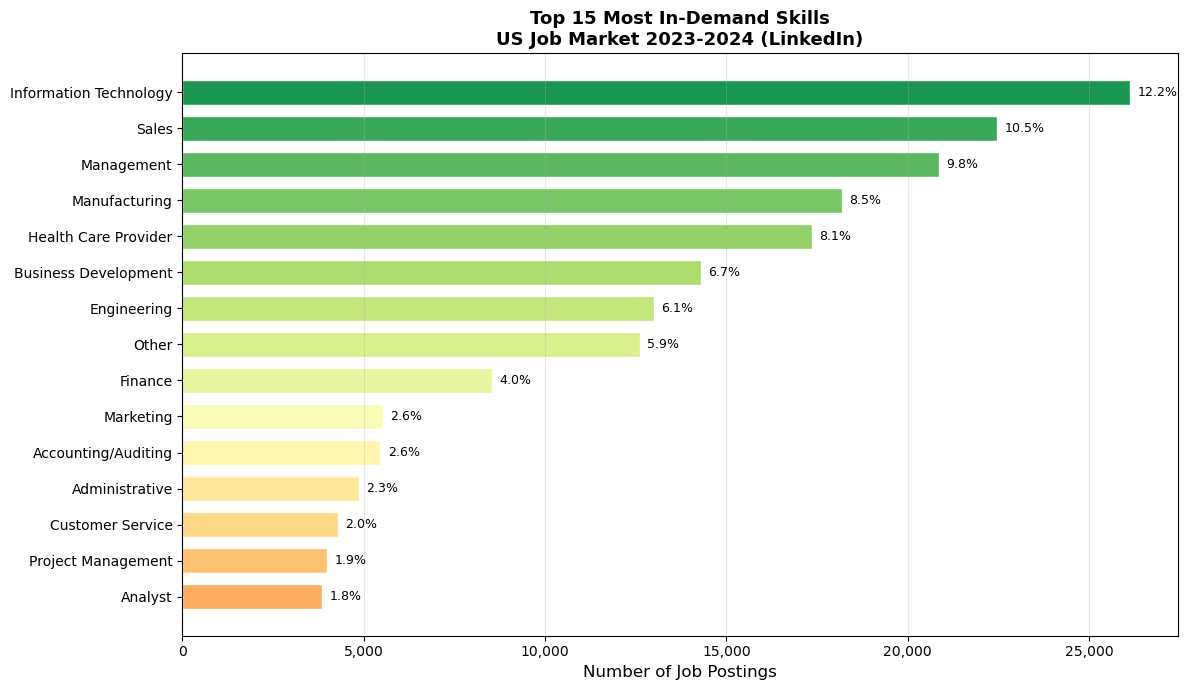

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

os.makedirs('outputs', exist_ok=True)

# Chart 1 - Top 15 Skills by Demand
skill_data = results['skill_demand'].head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn(
    np.linspace(0.3, 0.9, len(skill_data))[::-1]
)
bars = ax.barh(skill_data['skill_name'][::-1], 
               skill_data['job_count'][::-1],
               color=colors[::-1], edgecolor='white', height=0.7)

for bar, pct in zip(bars, skill_data['market_share_pct'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_title('Top 15 Most In-Demand Skills\nUS Job Market 2023-2024 (LinkedIn)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/01_skill_demand.png', dpi=150, bbox_inches='tight')
plt.show()

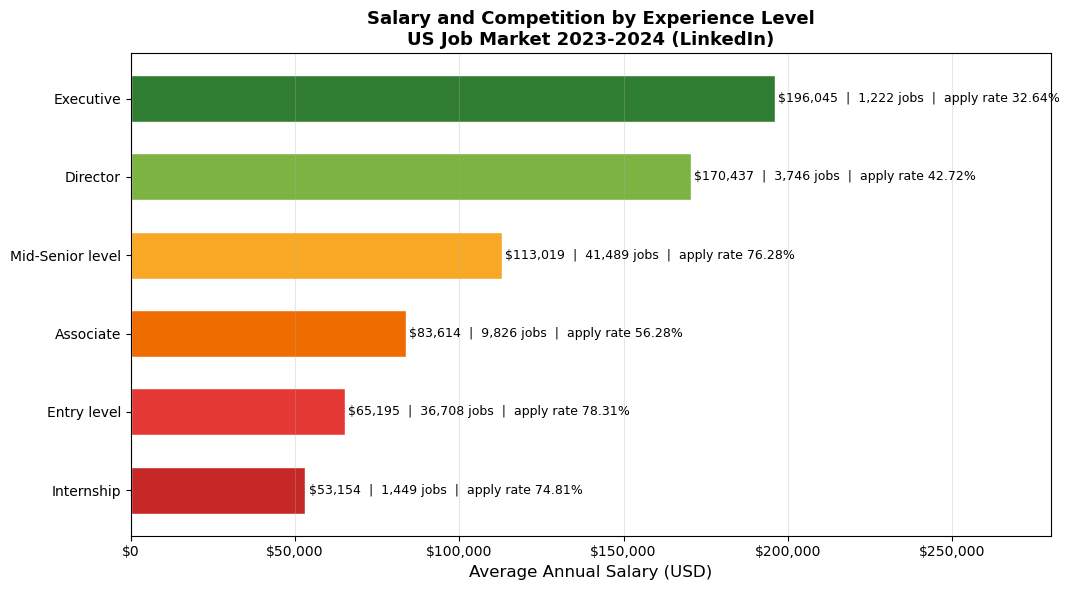

In [22]:
# Chart 2 - Salary by Experience Level
exp_data = results['exp_level'].sort_values('avg_salary', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#c62828', '#e53935', '#ef6c00', '#f9a825', '#7cb342', '#2e7d32']
bars = ax.barh(exp_data['exp_level'], exp_data['avg_salary'],
               color=colors, edgecolor='white', height=0.6)

for bar, row in zip(bars, exp_data.itertuples()):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'${row.avg_salary:,.0f}  |  {row.job_count:,} jobs  |  apply rate {row.apply_rate_pct}%',
            va='center', fontsize=9)

ax.set_xlabel('Average Annual Salary (USD)', fontsize=12)
ax.set_title('Salary and Competition by Experience Level\nUS Job Market 2023-2024 (LinkedIn)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, 280000)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/02_salary_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()

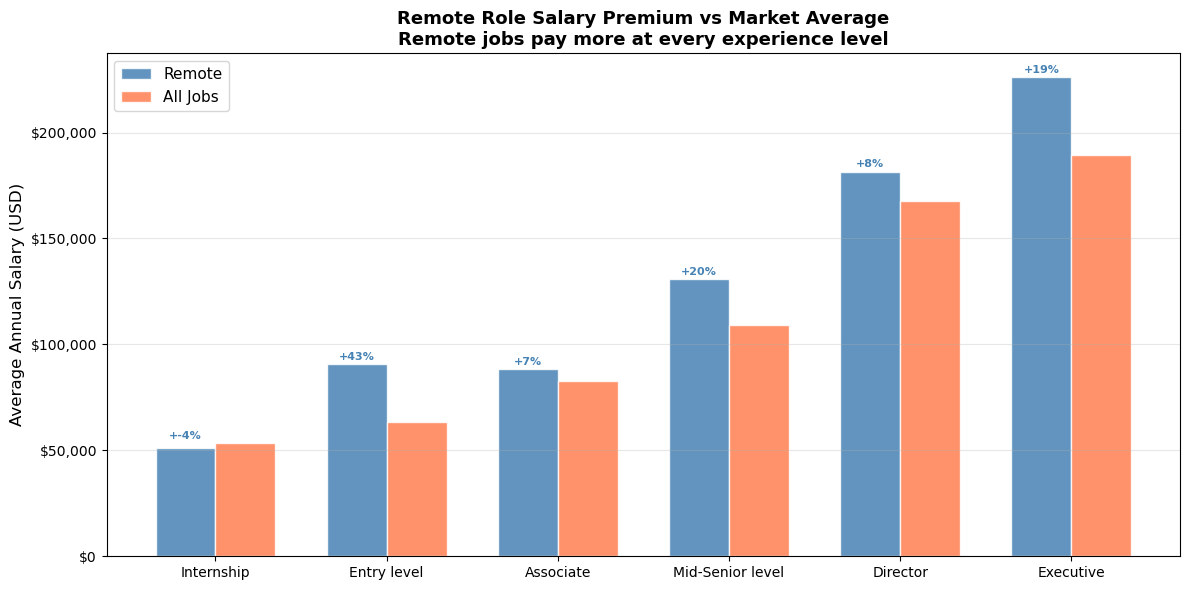

In [23]:
# Fix Chart 3 - Remote premium vs market average
conn = sqlite3.connect(db_path)

q_remote_fix = """
SELECT
    CASE 
        WHEN remote_allowed = 1 THEN 'Remote'
        ELSE 'All Jobs (incl. on-site)'
    END as job_type,
    formatted_experience_level as exp_level,
    COUNT(*) as job_count,
    ROUND(AVG(salary_annual), 0) as avg_salary
FROM postings
WHERE formatted_experience_level IS NOT NULL
    AND salary_annual IS NOT NULL
GROUP BY job_type, exp_level
"""
remote_fix = pd.read_sql_query(q_remote_fix, conn)

exp_order = ['Internship', 'Entry level', 'Associate',
             'Mid-Senior level', 'Director', 'Executive']

remote_vals = []
all_vals = []
for exp in exp_order:
    r = remote_fix[(remote_fix['exp_level']==exp) & 
                   (remote_fix['job_type']=='Remote')]['avg_salary']
    a = remote_fix[(remote_fix['exp_level']==exp) & 
                   (remote_fix['job_type']=='All Jobs (incl. on-site)')]['avg_salary']
    remote_vals.append(r.values[0] if len(r) > 0 else 0)
    all_vals.append(a.values[0] if len(a) > 0 else 0)

x = np.arange(len(exp_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, remote_vals, width, label='Remote',
               color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, all_vals, width, label='All Jobs',
               color='coral', alpha=0.85, edgecolor='white')

for b1, b2 in zip(bars1, bars2):
    if b1.get_height() > 0 and b2.get_height() > 0:
        premium = (b1.get_height() - b2.get_height()) / b2.get_height() * 100
        ax.text(b1.get_x() + width/2,
                max(b1.get_height(), b2.get_height()) + 2000,
                f'+{premium:.0f}%', ha='center', fontsize=8,
                color='steelblue', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(exp_order, fontsize=10)
ax.set_ylabel('Average Annual Salary (USD)', fontsize=12)
ax.set_title('Remote Role Salary Premium vs Market Average\n'
             'Remote jobs pay more at every experience level',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/03_remote_premium.png', dpi=150, bbox_inches='tight')
plt.show()

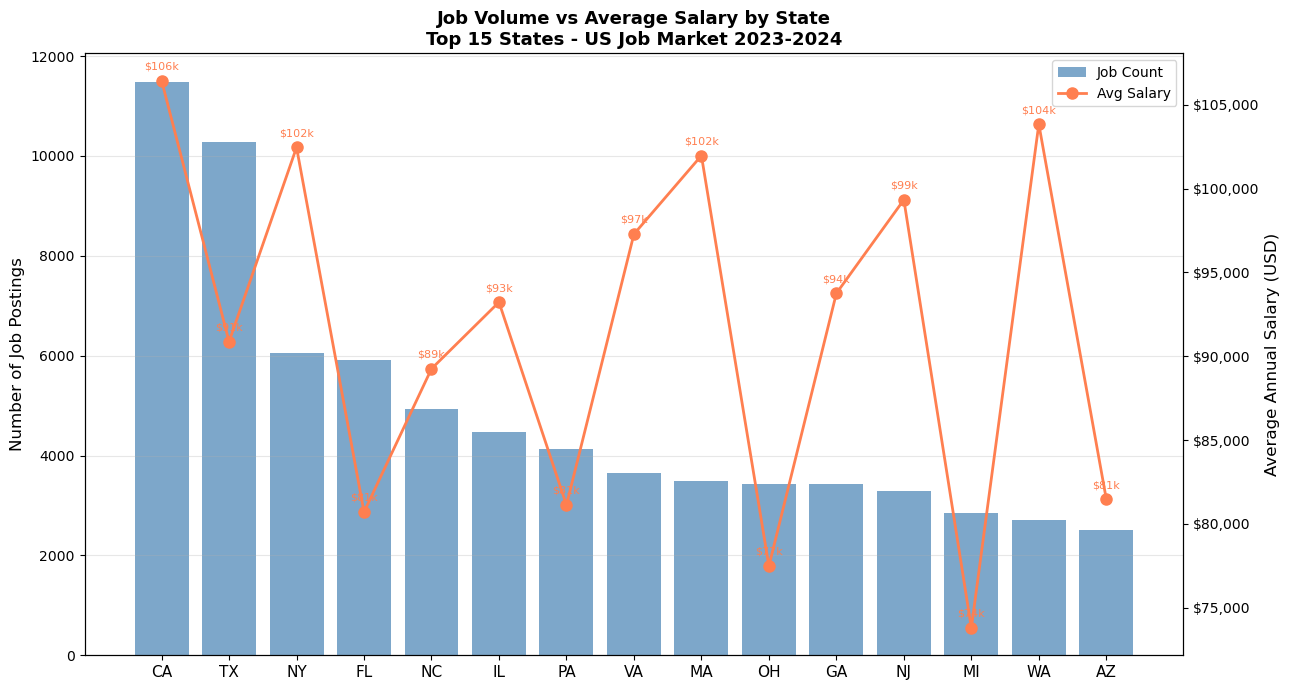

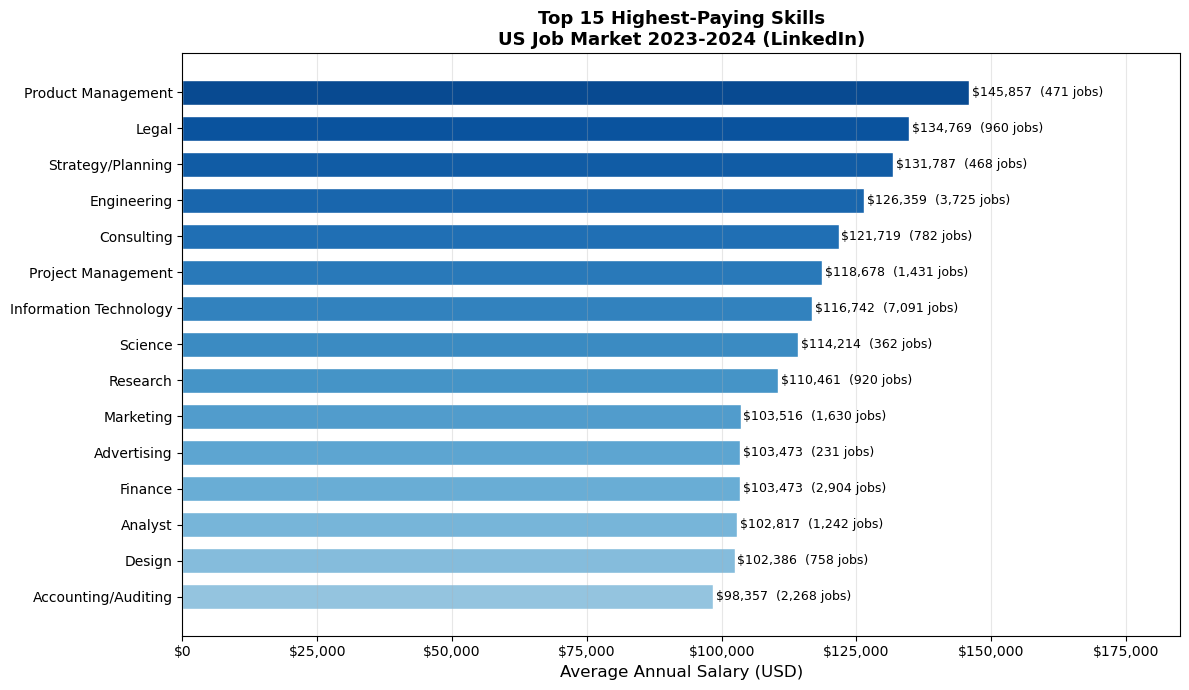

In [27]:
# Chart 4 - fix column name
fig, ax1 = plt.subplots(figsize=(13, 7))
ax2 = ax1.twinx()

x = np.arange(len(state_data))
bars = ax1.bar(x, state_data['total_jobs'],          # fixed
               color='steelblue', alpha=0.7, label='Job Count')
line = ax2.plot(x, state_data['avg_salary'],
                color='coral', marker='o', linewidth=2,
                markersize=8, label='Avg Salary')

ax1.set_xticks(x)
ax1.set_xticklabels(state_data['state'], fontsize=11)
ax1.set_ylabel('Number of Job Postings', fontsize=12)
ax2.set_ylabel('Average Annual Salary (USD)', fontsize=12)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

for i, sal in enumerate(state_data['avg_salary']):
    ax2.annotate(f'${sal/1000:.0f}k',
                 xy=(i, sal), xytext=(0, 8),
                 textcoords='offset points',
                 ha='center', fontsize=8, color='coral')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right', fontsize=10)

ax1.set_title('Job Volume vs Average Salary by State\n'
              'Top 15 States - US Job Market 2023-2024',
              fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/04_state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 5 - Salary by skill
skill_sal = results['salary_by_skill'].head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(skill_sal)))
bars = ax.barh(skill_sal['skill_name'][::-1],
               skill_sal['avg_salary'][::-1],
               color=colors, edgecolor='white', height=0.7)

for bar, row in zip(bars, skill_sal.iloc[::-1].itertuples()):
    ax.text(bar.get_width() + 500,
            bar.get_y() + bar.get_height()/2,
            f'${row.avg_salary:,.0f}  ({row.job_count:,} jobs)',
            va='center', fontsize=9)

ax.set_xlabel('Average Annual Salary (USD)', fontsize=12)
ax.set_title('Top 15 Highest-Paying Skills\n'
             'US Job Market 2023-2024 (LinkedIn)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
ax.set_xlim(0, 185000)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/05_salary_by_skill.png', dpi=150, bbox_inches='tight')
plt.show()